Using CPU. Note: This module is much faster with a GPU.


✅ Detected Number Plate: MH15BD8877


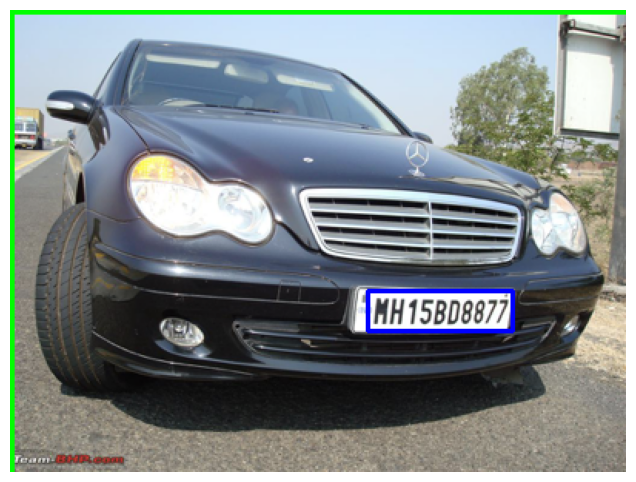

In [64]:
# =========================================================
# ROBUST INDIAN NUMBER PLATE RECOGNITION
# Plate Bounding Box + OCR Bounding Box
# =========================================================

import cv2
import matplotlib.pyplot as plt
import easyocr
import re

# ---------------------------------------------------------
# IMAGE PATH
# ---------------------------------------------------------
img_path = "/kaggle/input/car-number-plate-detection/datasets/cars_license_plate_new/test/images/Cars39.png"
# ---------------------------------------------------------
# LOAD IMAGE
# ---------------------------------------------------------
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError("Image not found!")

img_copy = img.copy()

# ---------------------------------------------------------
# PREPROCESSING
# ---------------------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)

# ---------------------------------------------------------
# FIND NUMBER PLATE CONTOUR
# ---------------------------------------------------------
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate_contour = None
for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    if len(approx) == 4:
        plate_contour = approx
        break

# ---------------------------------------------------------
# OCR + RULE BASED CORRECTION
# ---------------------------------------------------------
reader = easyocr.Reader(['en'], gpu=False)

VALID_STATE_CODES = {
    "MH","KA","TN","DL","AP","TS","KL","GJ","RJ",
    "UP","MP","PB","HR","WB","OD","BR","CG","GA"
}

def correct_indian_plate(text):
    text = re.sub(r'[^A-Z0-9]', '', text)
    if len(text) < 8:
        return text

    state = text[:2]
    corrections = {"HH":"MH","IH":"MH","MN":"MH","NH":"MH"}
    if state not in VALID_STATE_CODES:
        state = corrections.get(state, state)

    return state + text[2:]

plate_text = "Not Detected"

if plate_contour is not None:
    x, y, w, h = cv2.boundingRect(plate_contour)
    plate_img = img[y:y+h, x:x+w]

    results = reader.readtext(
        plate_img,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    )

    # ---- DRAW PLATE BOUNDING BOX (GREEN) ----
    cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0,255,0), 3)

    for (bbox, text, conf) in results:
        raw_text = text
        plate_text = correct_indian_plate(raw_text)

        # ---- OCR TEXT BOUNDING BOX (RED) ----
        (tl, tr, br, bl) = bbox
        tl = (int(tl[0]+x), int(tl[1]+y))
        br = (int(br[0]+x), int(br[1]+y))

        cv2.rectangle(img_copy, tl, br, (255,0,0), 2)

    # ---- PRINT FINAL TEXT ----
    cv2.putText(img_copy, plate_text, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1,
                (0,0,255), 2)

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------
print("✅ Detected Number Plate:", plate_text)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()